# Notebook 03 - Scenario Analysis (Phase 5)

Runs six policy scenarios through the calibrated agent-based simulation (500 episodes each) and quantifies their effect on the KPI set (sessions, energy, revenue, CO₂, waiting time, utilisation) against the baseline, with paired Wilcoxon signed-rank tests.

**Scenarios:** baseline, EV adoption growth (+50% / +100% arrivals), Time-of-Use pricing (£0.45 peak / £0.15 off-peak), carbon-aware incentives, and a combined policy.

**Purpose:** establish which levers actually move network behaviour at the current scale - and, critically, to motivate the Phase 6 RL design by showing where static pricing does and does not work.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

from simulation.scenario_engine import ScenarioEngine, SCENARIOS

sns.set_theme(style="whitegrid")

# BASE_SEED = 42

print("Imports OK")
print(f"Scenarios defined: {list(SCENARIOS.keys())}")

Imports OK
Scenarios defined: ['baseline', 'ev_growth_low', 'ev_growth_high', 'tou_pricing', 'carbon_incentive', 'combined']


In [2]:
engine  = ScenarioEngine(n_episodes=500, base_seed=int(42))
results = engine.run_all()

Running: Baseline (500 episodes)...
  Done. Mean sessions: 25.6
Running: EV Adoption Growth (Low) (500 episodes)...
  Done. Mean sessions: 38.2
Running: EV Adoption Growth (High) (500 episodes)...
  Done. Mean sessions: 51.2
Running: Time-of-Use Pricing (500 episodes)...
  Done. Mean sessions: 25.6
Running: Carbon-Aware Incentives (500 episodes)...
  Done. Mean sessions: 25.6
Running: Combined Policy (500 episodes)...
  Done. Mean sessions: 25.6


In [3]:
summary = engine.compare_kpis(results)

kpi_display = [
    "sessions_completed_mean",
    "energy_kwh_mean",
    "revenue_gbp_mean",
    "co2_g_mean",
    "avg_wait_hrs_mean",
    "avg_utilisation_mean",
]

print("=== KPI Summary - Mean across 500 episodes ===")
print(summary[["scenario"] + kpi_display].to_string())

=== KPI Summary - Mean across 500 episodes ===
                                   scenario  sessions_completed_mean  energy_kwh_mean  revenue_gbp_mean   co2_g_mean  avg_wait_hrs_mean  avg_utilisation_mean
key                                                                                                                                                          
baseline                           Baseline                   25.598        671.76530         201.52954  38934.40010           0.004998              0.121209
ev_growth_low      EV Adoption Growth (Low)                   38.162        992.67430         297.80248  57533.75138           0.094920              0.181328
ev_growth_high    EV Adoption Growth (High)                   51.196       1340.82902         402.24868  77712.22480           0.353906              0.243716
tou_pricing             Time-of-Use Pricing                   25.598        665.61938         277.90088  38578.20292           0.005148              0.120562
carbo

In [4]:
baseline_means = summary.loc["baseline", kpi_display]

pct_change = summary[kpi_display].apply(
    lambda col: (col - baseline_means[col.name]) / baseline_means[col.name] * 100
)
pct_change.insert(0, "scenario", summary["scenario"])

print("=== Percentage Change vs Baseline ===")
print(pct_change.to_string())

=== Percentage Change vs Baseline ===
                                   scenario  sessions_completed_mean  energy_kwh_mean  revenue_gbp_mean  co2_g_mean  avg_wait_hrs_mean  avg_utilisation_mean
key                                                                                                                                                         
baseline                           Baseline                 0.000000         0.000000          0.000000    0.000000           0.000000              0.000000
ev_growth_low      EV Adoption Growth (Low)                49.081960        47.771000         47.771131   47.770997        1799.159664             49.599616
ev_growth_high    EV Adoption Growth (High)               100.000000        99.597839         99.597875   99.597848        6980.952381            101.071211
tou_pricing             Time-of-Use Pricing                 0.000000        -0.914891         37.895854   -0.914865           3.001200             -0.533130
carbon_incentive    

In [5]:
kpi_cols = [
    "sessions_completed", "energy_kwh", "revenue_gbp",
    "co2_g", "avg_wait_hrs", "avg_utilisation"
]

wilcoxon_results = []
for kpi in kpi_cols:
    df_w = engine.wilcoxon_vs_baseline(results, kpi=kpi)
    wilcoxon_results.append(df_w)

df_wilcoxon = pd.concat(wilcoxon_results, ignore_index=True)
print("=== Wilcoxon Signed-Rank Test vs Baseline ===")
print(df_wilcoxon[["scenario", "kpi", "baseline_mean",
                    "scenario_mean", "pct_change",
                    "p_value", "significant"]].to_string())

=== Wilcoxon Signed-Rank Test vs Baseline ===
                     scenario                 kpi  baseline_mean  scenario_mean   pct_change       p_value  significant
0    EV Adoption Growth (Low)  sessions_completed      25.598000      38.162000    49.081960  1.042483e-83         True
1   EV Adoption Growth (High)  sessions_completed      25.598000      51.196000   100.000000  1.202406e-83         True
2         Time-of-Use Pricing  sessions_completed      25.598000      25.598000     0.000000           NaN        False
3     Carbon-Aware Incentives  sessions_completed      25.598000      25.596000    -0.007813  3.173105e-01        False
4             Combined Policy  sessions_completed      25.598000      25.598000     0.000000           NaN        False
5    EV Adoption Growth (Low)          energy_kwh     671.765300     992.674300    47.771000  1.984413e-83         True
6   EV Adoption Growth (High)          energy_kwh     671.765300    1340.829020    99.597839  1.264716e-83        

c:\Users\nguye\Downloads\DS_projects\ev_digital_twin\.venv\Lib\site-packages\scipy\stats\_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


### Interpretation - KPIs and significance

**EV adoption growth is the dominant lever.** Doubling arrivals (EV Growth High) doubles energy, revenue and CO₂ (all ≈ +100%) and raises mean waiting time by **+6,981%** (0.005 → 0.354 hrs) - a sharply non-linear congestion onset as utilisation climbs from 12% to 24%. All adoption effects are strongly significant (Wilcoxon p < 10⁻⁸³).

**Pricing changes revenue, not behaviour.** Time-of-Use pricing raises revenue **+38%** (£201 → £278) while leaving sessions, energy and CO₂ essentially unchanged. At 12% baseline utilisation the network is far from capacity, so price re-values the same load rather than reshaping it.

**Carbon incentives are a weak lever here.** CO₂ falls only 0.7% and the change is not significant (p = 0.32) - at low utilisation there is little discretionary load to shift.

**The `NaN` p-values are a result, not a bug.** For ToU and Combined, session counts are *identical* to baseline across all 500 paired episodes, so every paired difference is zero and the Wilcoxon statistic is undefined. This is the empirical signature of **perfectly price-inelastic demand** at low utilisation: with drivers retrying rather than abandoning, price cannot change how many sessions occur. This directly motivates the Phase 6 redesign - RL pricing is trained under high adoption (2×) with an abandonment mechanism, the regime where a price signal actually has something to act on.

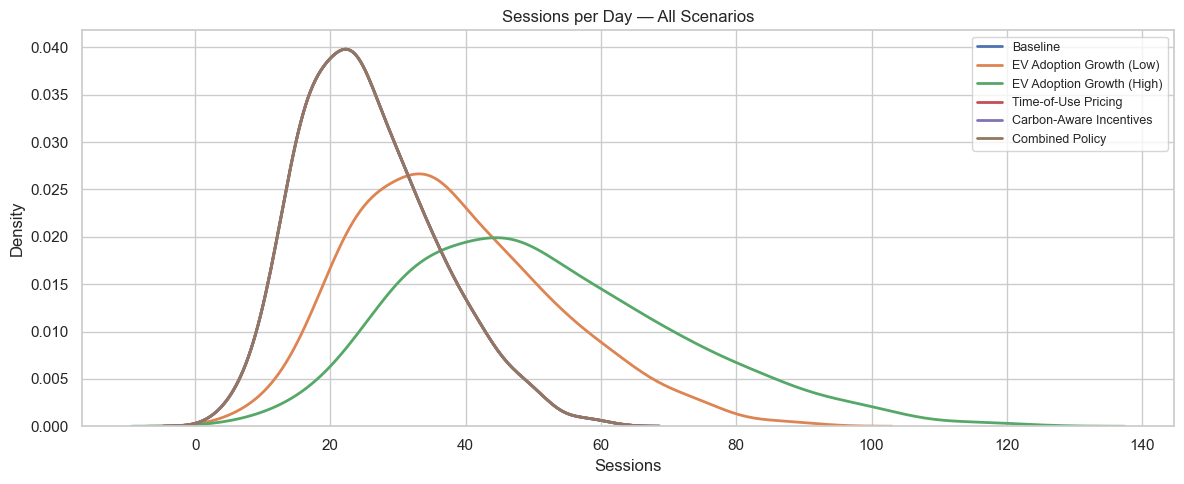

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

for key, df in results.items():
    sns.kdeplot(
        df["sessions_completed"],
        ax=ax,
        label=SCENARIOS[key].name,
        fill=False,
        linewidth=2
    )

ax.set_title("Sessions per Day - All Scenarios")
ax.set_xlabel("Sessions")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../results/figures/scenario_sessions.png", dpi=150)
plt.show()

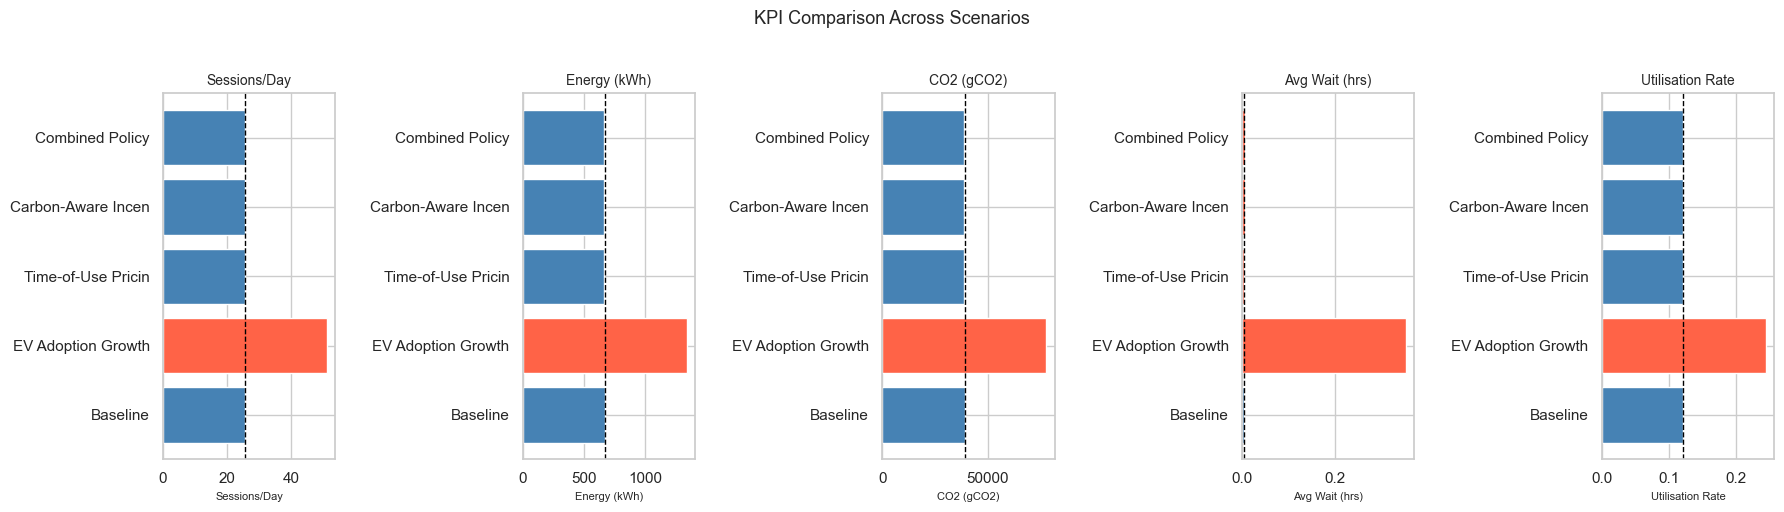

In [ ]:
kpi_labels = {
    "sessions_completed_mean": "Sessions/Day",
    "energy_kwh_mean":         "Energy (kWh)",
    "co2_g_mean":              "CO2 (gCO2)",
    "avg_wait_hrs_mean":       "Avg Wait (hrs)",
    "avg_utilisation_mean":    "Utilisation Rate",
}

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, (col, label) in zip(axes, kpi_labels.items()):
    vals     = summary[col].values
    names = [s[:18] for s in summary["scenario"].values]
    baseline = vals[0]
    colours  = ["steelblue" if v <= baseline else "tomato" for v in vals]

    ax.barh(names, vals, color=colours)
    ax.axvline(baseline, color="black", linestyle="--", linewidth=1, label="Baseline")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel(label, fontsize=8)

plt.suptitle("KPI Comparison Across Scenarios", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/scenario_kpi_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

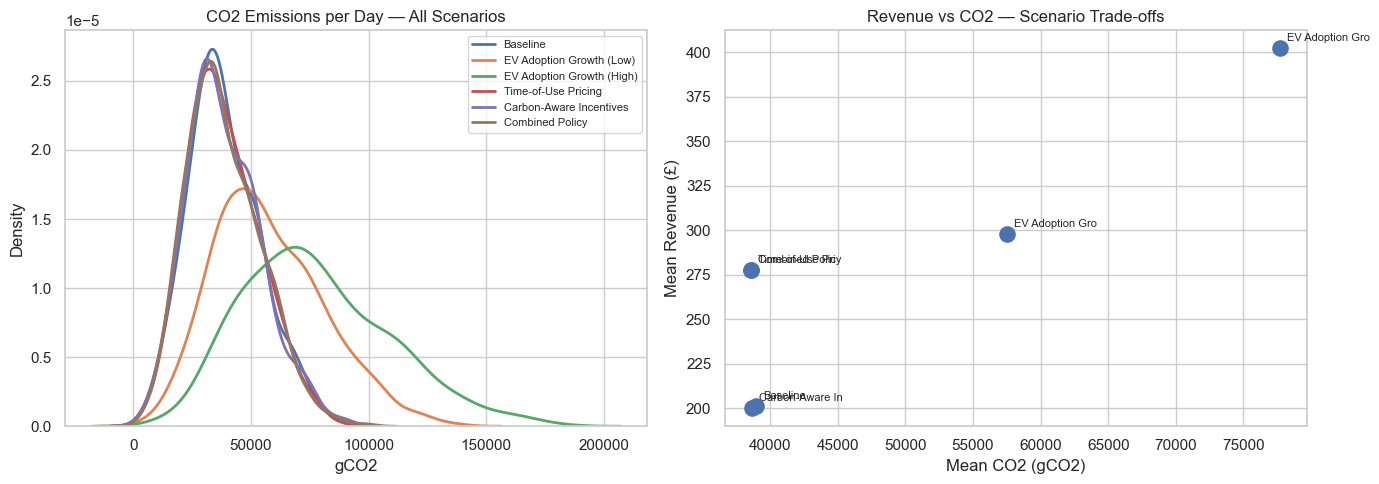

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CO2 distribution per scenario
for key, df in results.items():
    sns.kdeplot(
        df["co2_g"],
        ax=axes[0],
        label=SCENARIOS[key].name,
        fill=False,
        linewidth=2
    )
axes[0].set_title("CO2 Emissions per Day - All Scenarios")
axes[0].set_xlabel("gCO2")
axes[0].legend(fontsize=8)

# Revenue vs CO2 scatter (mean per scenario)
axes[1].scatter(
    summary["co2_g_mean"],
    summary["revenue_gbp_mean"],
    s=120,
    zorder=5
)
for i, row in summary.iterrows():
    axes[1].annotate(
        row["scenario"][:15],
        (row["co2_g_mean"], row["revenue_gbp_mean"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )
axes[1].set_title("Revenue vs CO2 - Scenario Trade-offs")
axes[1].set_xlabel("Mean CO2 (gCO2)")
axes[1].set_ylabel("Mean Revenue (£)")

plt.tight_layout()
plt.savefig("../results/figures/scenario_co2_revenue.png", dpi=150)
plt.show()

### Interpretation - distributions

The session-count densities show the two adoption scenarios shifted right with wider spread (Negative-Binomial overdispersion compounding at higher volume), while all three pricing/carbon scenarios sit *exactly* on the baseline curve - visual confirmation that pricing does not change demand at this scale. The CO₂ densities mirror this. The revenue-vs-CO₂ view shows ToU and Combined lifting revenue at unchanged emissions: a pure pricing effect with no behavioural response.

**Headline for the write-up:** at current utilisation, infrastructure and adoption dominate; static pricing interventions produce sub-1% behavioural effects. Pricing becomes a meaningful control lever only under congestion - exactly the regime Phase 6 targets.

In [10]:
import duckdb

con = duckdb.connect("../data/ev_twin.duckdb")

con.execute("DROP TABLE IF EXISTS scenario_results")
con.execute("DROP TABLE IF EXISTS scenario_summary")

# Save episode-level results
all_results = pd.concat(results.values(), ignore_index=True)
con.execute("CREATE TABLE scenario_results AS SELECT * FROM all_results")

# Reset index in Python before passing to DuckDB
summary_reset = summary.reset_index()
con.execute("CREATE TABLE scenario_summary AS SELECT * FROM summary_reset")

con.close()
print(f"Saved {len(all_results)} episode records to DuckDB")
print(f"Saved {len(summary_reset)} scenario summaries to DuckDB")

Saved 3000 episode records to DuckDB
Saved 6 scenario summaries to DuckDB


In [13]:
kpi_display_names = {
    "sessions_completed": "Sessions/Day",
    "energy_kwh":         "Energy (kWh)",
    "revenue_gbp":        "Revenue (£)",
    "co2_g":              "CO2 (gCO2)",
    "avg_wait_hrs":       "Avg Wait (hrs)",
    "avg_utilisation":    "Utilisation"
}

rows = []
for key, df in results.items():
    row = {"Scenario": SCENARIOS[key].name}
    for col, label in kpi_display_names.items():
        mean = df[col].mean()
        std  = df[col].std()
        row[label] = f"{mean:.2f} ± {std:.2f}"
    rows.append(row)

report = pd.DataFrame(rows).set_index("Scenario")
print("=== Policy Evaluation Report ===")
print(report.to_string())

=== Policy Evaluation Report ===
                            Sessions/Day      Energy (kWh)      Revenue (£)           CO2 (gCO2) Avg Wait (hrs)  Utilisation
Scenario                                                                                                                    
Baseline                   25.60 ± 10.04   671.77 ± 266.37   201.53 ± 79.91  38934.40 ± 15438.13    0.00 ± 0.02  0.12 ± 0.05
EV Adoption Growth (Low)   38.16 ± 15.05   992.67 ± 402.56  297.80 ± 120.77  57533.75 ± 23331.83    0.09 ± 0.19  0.18 ± 0.07
EV Adoption Growth (High)  51.20 ± 20.08  1340.83 ± 537.24  402.25 ± 161.17  77712.22 ± 31137.78    0.35 ± 0.46  0.24 ± 0.10
Time-of-Use Pricing        25.60 ± 10.04   665.62 ± 262.91  277.90 ± 111.26  38578.20 ± 15237.72    0.01 ± 0.02  0.12 ± 0.05
Carbon-Aware Incentives    25.60 ± 10.04   667.11 ± 269.99   200.13 ± 81.00  38664.77 ± 15647.95    0.01 ± 0.03  0.12 ± 0.05
Combined Policy            25.60 ± 10.04   665.85 ± 268.24  278.03 ± 113.26  38591.63 ± 1554